# Кластеризация сигналов сцинтилляционного детектора

Сиды зафиксированы (`random_state=42`)

In [1]:
%matplotlib inline
import gzip
import shutil
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_FILE = Path("Run200_Wave_0_1.txt")
SUBMISSION_PATH = Path("submission.csv")

# исходник большой (~71 МБ), в репозиторий кладём gzip-версию.
# если рядом лежит только .gz — разворачиваем при первом запуске.
if not DATA_FILE.exists():
    gz = Path("Run200_Wave_0_1.txt.gz")
    if gz.exists():
        print("распаковываю", gz, "->", DATA_FILE)
        with gzip.open(gz, "rb") as src, open(DATA_FILE, "wb") as dst:
            shutil.copyfileobj(src, dst)
    else:
        raise FileNotFoundError(
            "нужен Run200_Wave_0_1.txt или Run200_Wave_0_1.txt.gz рядом с ноутбуком"
        )

распаковываю Run200_Wave_0_1.txt.gz -> Run200_Wave_0_1.txt


## Загрузка

Таблица с разделителем-пробелом: первые 4 столбца метадата (timestamp и т.п.), другие 500
точек АЦП. Импульс направлен вниз, поэтому baseline correction — медиану первых 120 точек вычитаю
в обратную сторону, чтобы пик стал положительным.

In [2]:
raw_table = np.loadtxt(DATA_FILE, dtype=np.float32)
print("таблица:", raw_table.shape)

meta = pd.DataFrame(raw_table[:, :4], columns=["timestamp", "evt_a", "evt_b", "length"])
raw_signal = raw_table[:, 4:504]

baseline = np.median(raw_signal[:, :120], axis=1)
signal = baseline[:, None] - raw_signal
positive_signal = np.clip(signal, 0, None)

assert raw_table.shape == (23479, 504)
assert np.isfinite(signal).all()

print("бейзлайн медиана:", float(np.median(baseline)))
print("сигнал после коррекции минимум и максимум:", signal.min(), signal.max())

таблица: (23479, 504)
бейзлайн медиана: 14823.0
сигнал после коррекции минимум и максимум: -16.0 14824.0


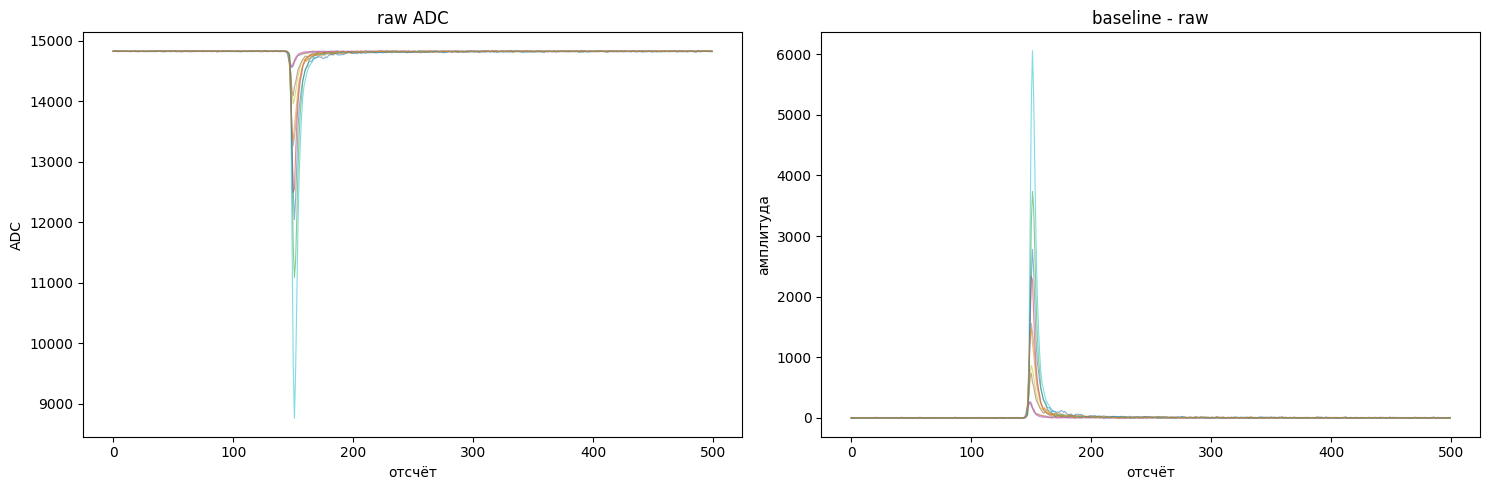

медианная позиция пика: 150


In [3]:
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(raw_signal.shape[0], 12, replace=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
for i in idx:
    ax[0].plot(raw_signal[i], lw=0.8, alpha=0.55)
    ax[1].plot(signal[i],     lw=0.8, alpha=0.55)
ax[0].set(title="raw ADC", xlabel="отсчёт", ylabel="ADC")
ax[1].set(title="baseline - raw", xlabel="отсчёт", ylabel="амплитуда")
plt.tight_layout(); plt.show()

print("медианная позиция пика:", int(np.median(np.argmax(signal, axis=1))))

Пик почти всегда около 150, дальше всё считаю в окне относительно положения максимума.

__Физика__: разделяем гамму/нейтроны в паратерфениле по форме хвоста (у нейтронов он тяжелее)

__Главный признак__: PSD = заряд хвоста / заряд широкого окна

На каждое событие собираем примерно 20 фич:
1. PSD
2. Амплитуда и площади в разных окнах
3. Время спада, центроид и ширина
4. Шумы (до импульса и в дальнем хвосте) + статистика формы

In [4]:
def fall_time(post_peak, amp, frac):
    below = np.flatnonzero(post_peak <= frac * amp)
    return int(below[0]) if below.size else int(len(post_peak) - 1)


def rise_time(before_peak, amp):
    a = np.flatnonzero(before_peak >= 0.10 * amp)
    b = np.flatnonzero(before_peak >= 0.90 * amp)
    return float(b[0] - a[0]) if a.size and b.size else np.nan


n_rows, n_points = signal.shape
peak_position = np.argmax(signal, axis=1).astype(np.int16)
amplitude = signal[np.arange(n_rows), peak_position]
amp_safe = np.maximum(amplitude, 1e-6)

short_area = np.zeros(n_rows)
long_area  = np.zeros(n_rows)
tail_area  = np.zeros(n_rows)
tail_ratio_arr = np.zeros(n_rows)
centroid = np.zeros(n_rows)
width    = np.zeros(n_rows)
rise_arr = np.zeros(n_rows)
t50 = np.zeros(n_rows); t25 = np.zeros(n_rows); t10 = np.zeros(n_rows); t05 = np.zeros(n_rows)

for i in range(n_rows):
    p = int(peak_position[i])
    amp = float(amp_safe[i])
    start = max(0, p - 8)
    short_end = min(n_points, p + 45)
    long_end  = min(n_points, p + 220)
    tail_start = min(n_points, p + 60)

    pulse = positive_signal[i]
    short_area[i] = pulse[start:short_end].sum()
    long_area[i]  = pulse[start:long_end].sum()
    tail_area[i]  = pulse[short_end:long_end].sum()
    tail_ratio_arr[i] = pulse[tail_start:long_end].sum() / (pulse[start:long_end].sum() + 1e-6)

    post = signal[i, p:]
    t50[i] = fall_time(post, amp, 0.50)
    t25[i] = fall_time(post, amp, 0.25)
    t10[i] = fall_time(post, amp, 0.10)
    t05[i] = fall_time(post, amp, 0.05)
    rise_arr[i] = rise_time(signal[i, :p + 1], amp)

    w = pulse[start:long_end]
    x = np.arange(start, long_end) - p
    ws = w.sum() + 1e-6
    c = (x * w).sum() / ws
    centroid[i] = c
    width[i] = np.sqrt((((x - c) ** 2) * w).sum() / ws)

features = pd.DataFrame({
    "pre_std": raw_signal[:, :120].std(axis=1),
    "tail_std": raw_signal[:, 350:].std(axis=1),
    "peak_position": peak_position,
    "amplitude": amplitude,
    "area_total": positive_signal.sum(axis=1),
    "short_area": short_area,
    "long_area": long_area,
    "tail_area": tail_area,
    "psd": tail_area / (long_area + 1e-6),
    "short_fraction": short_area / (long_area + 1e-6),
    "tail_ratio": tail_ratio_arr,
    "t50": t50, "t25": t25, "t10": t10, "t05": t05,
    "rise_10_90": rise_arr,
    "centroid": centroid,
    "width": width,
    "skew_120_260": skew(signal[:, 120:260], axis=1),
    "kurt_120_260": kurtosis(signal[:, 120:260], axis=1),
}).replace([np.inf, -np.inf], np.nan)
features = features.fillna(features.median(numeric_only=True))

print("всего признаков:", features.shape[1])
features.head(3).round(3)

всего признаков: 20


,pre_std,tail_std,peak_position,amplitude,area_total,short_area,long_area,tail_area,psd,short_fraction,tail_ratio,t50,t25,t10,t05,rise_10_90,centroid,width,skew_120_260,kurt_120_260
0,2.7610,3.2250,149,529.0000,4597.0000,3871.0000,4367.0000,496.0000,0.1140,0.8860,0.0910,4.0000,7.0000,11.0000,15.0000,3.0000,17.0020,36.9630,4.2000,17.9210
1,2.6750,2.7020,150,1902.0000,12836.0000,11714.0000,12330.0000,616.0000,0.0500,0.9500,0.0410,4.0000,6.0000,9.0000,11.0000,2.0000,8.5630,26.9710,4.5270,20.6170
2,2.4560,2.9560,151,2558.0000,17290.0000,16270.0000,16876.0000,606.0000,0.0360,0.9640,0.0310,3.0000,5.0000,8.0000,13.0000,3.0000,6.0290,23.5330,4.4890,20.1860


## EDA

Смотрю распределения, выбросы, корреляции, чтобы понять, какие признаки важно оставить для дальнейшего ресерча

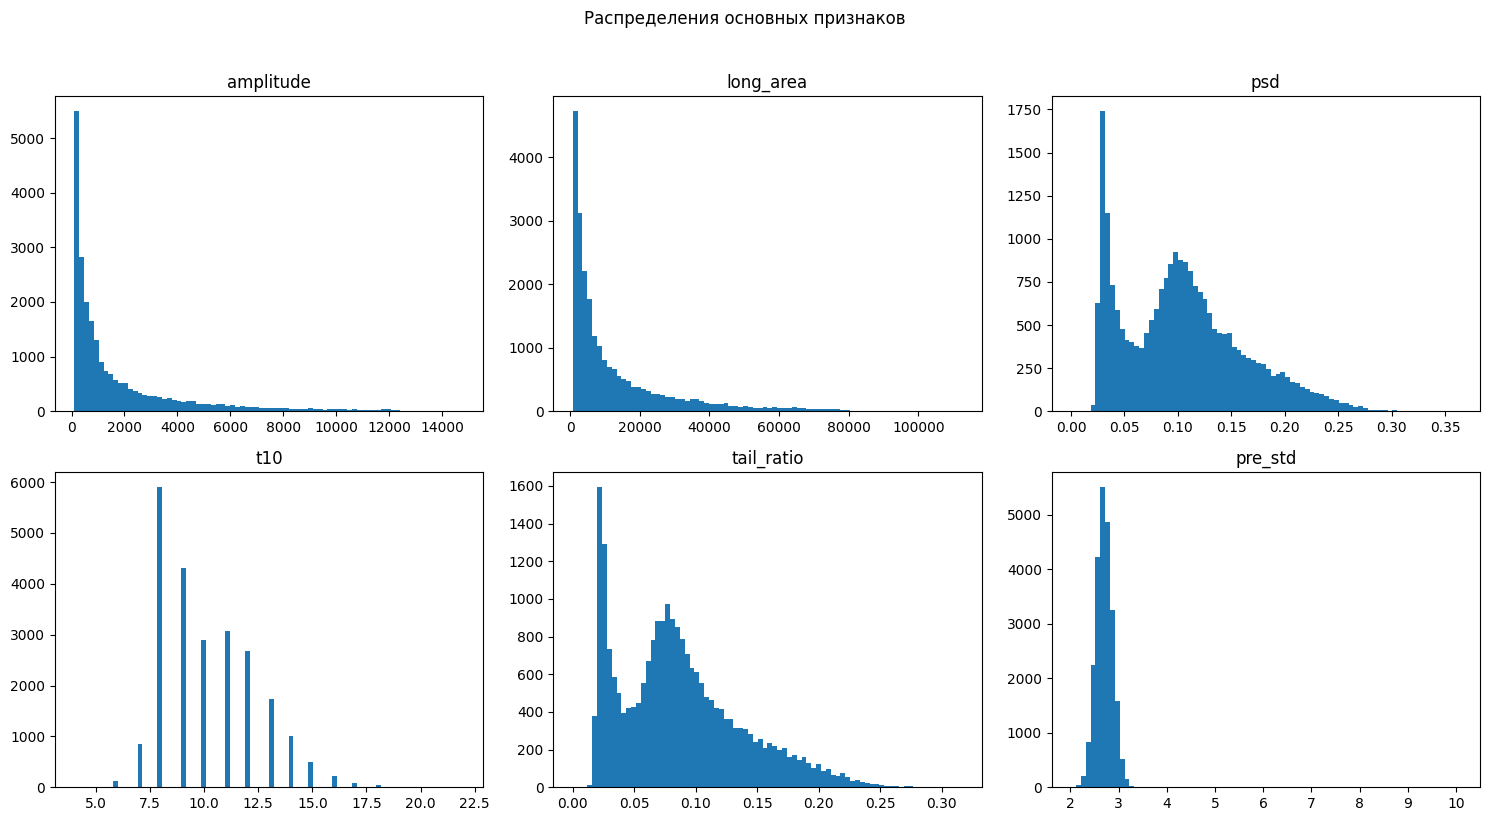

In [5]:
cols_plot = ["amplitude", "long_area", "psd", "t10", "tail_ratio", "pre_std"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), cols_plot):
    ax.hist(features[col], bins=80)
    ax.set(title=col)
fig.suptitle("Распределения основных признаков", y=1.02)
plt.tight_layout(); plt.show()

### Первичный анализ распределения признаков:

* **Амплитуда и площади:** Распределения сильно скошены вправо, есть длинный тяжёлый хвост из больших импульсов.
* **Признак `psd`:** Чётко разделяется на два режима, уже на этом этапе наглядно видно присутствие двух физических групп (гамма и нейтроны).
* **Шум (`pre_std`):** Большинство событий сидит компактно в районе ~2.7. Детектор имеет однородный шум, поэтому аномально высокий `pre_std` будет отличным маркером для отсева странных событий (артефактов/наводок).

In [6]:
(features[["amplitude", "long_area", "psd", "tail_ratio", "t10", "pre_std", "peak_position"]]
 .quantile([0.01, 0.05, 0.5, 0.95, 0.99])
 .T.rename(columns={0.01: "q01", 0.05: "q05", 0.5: "median", 0.95: "q95", 0.99: "q99"})
 .round(3))

,q01,q05,median,q95,q99
amplitude,121.5000,142.0000,813.0000,7187.1000,11066.8800
long_area,1040.0000,1294.0000,6267.0000,48351.0000,72627.5200
psd,0.0260,0.0290,0.1000,0.2110,0.2520
tail_ratio,0.0190,0.0220,0.0800,0.1860,0.2230
t10,7.0000,8.0000,10.0000,14.0000,16.0000
pre_std,2.3140,2.4250,2.6980,2.9860,3.1110
peak_position,146.0000,147.0000,150.0000,151.0000,152.0000


### Границы признаков и отсечка выбросов (по квантилям):

* **Амплитуда сигнала:** Основной диапазон зажат между $q_{01} \approx 121$ (совсем слабые события на уровне шума) и $q_{99} \approx 11\,067$ (события, подошедшие вплотную к насыщению АЦП).
* **Положение пика (`peak_position`):** Стабильно держится в узком интервале **149–151**. Фаза импульса не плывет.
* **Шум претриггера (`pre_std`):** Граница $q_{99}$ находится в районе **3.1**. Всё, что выше этого значения, можно смело считать шумным претриггером и отправлять в фильтр, в дальнейшем можем отсечь

__Строим хитмап для признаков и определения коррелирующих признаков и анализа зависимостей__

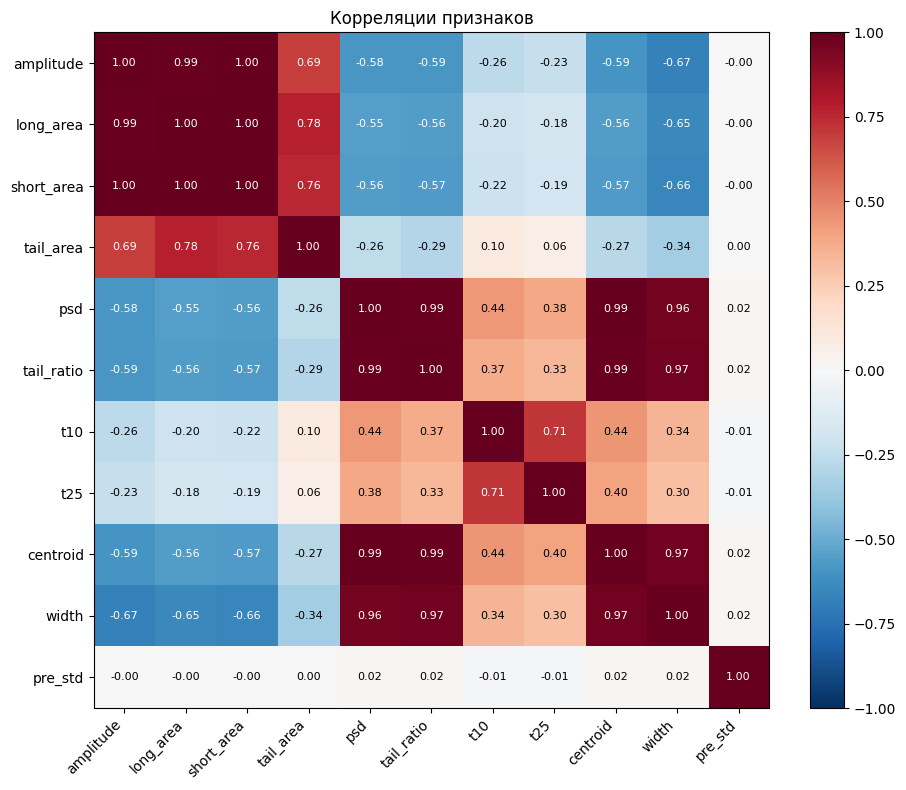

In [7]:
corr_cols = ["amplitude", "long_area", "short_area", "tail_area", "psd",
             "tail_ratio", "t10", "t25", "centroid", "width", "pre_std"]
corr = features[corr_cols].corr().values

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for r in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, r, f"{corr[r, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr[r, j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Корреляции признаков")
plt.tight_layout(); plt.show()

Амплитуда и площади несут практически одинаковую информацию (чем больше пик, тем больше и интеграл). А вот параметры `PSD` и `tail_ratio` с амплитудой почти не коррелируют. Они описывают форму хвоста, то есть характеристику, которая не зависит от общего масштаба и энергии импульса.

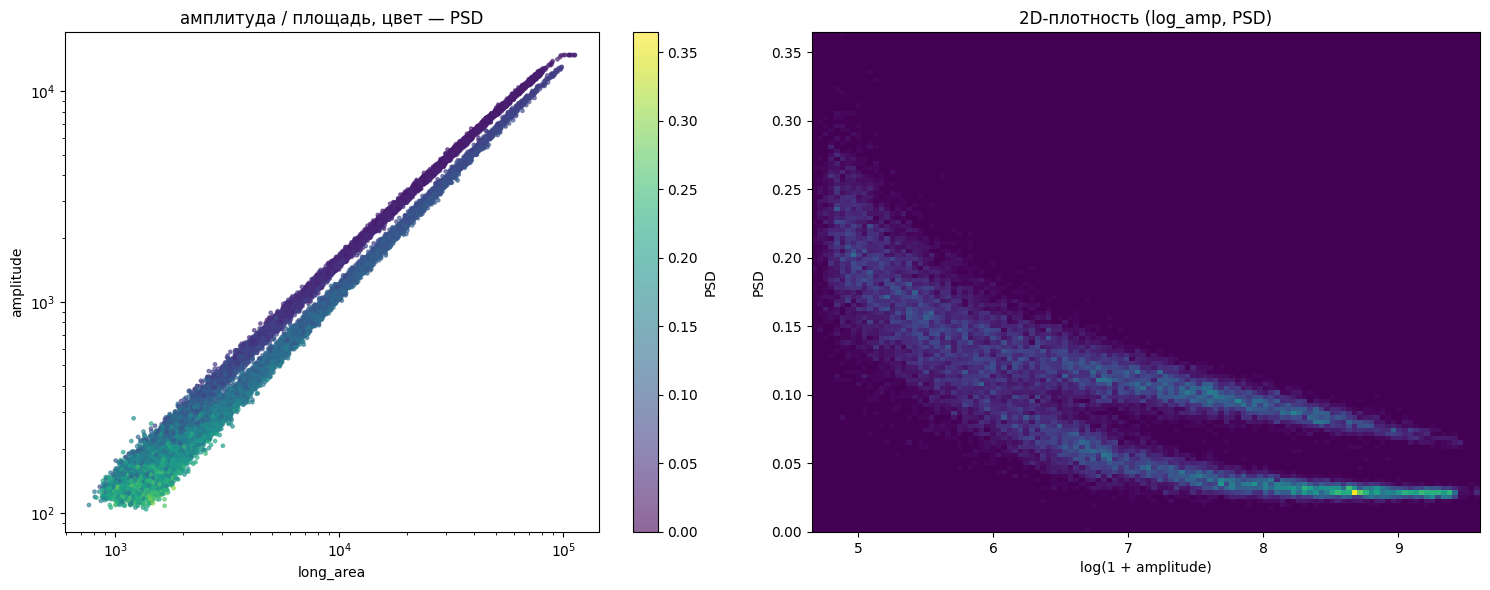

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sc = ax[0].scatter(features.long_area, features.amplitude, c=features.psd, s=6, alpha=0.6)
plt.colorbar(sc, ax=ax[0], label="PSD")
ax[0].set(xscale="log", yscale="log", xlabel="long_area", ylabel="amplitude",
          title="амплитуда / площадь, цвет — PSD")

ax[1].hist2d(np.log1p(features.amplitude), features.psd, bins=120)
ax[1].set(xlabel="log(1 + amplitude)", ylabel="PSD",
          title="2D-плотность (log_amp, PSD)")
plt.tight_layout(); plt.show()

На правом графике видно две плотные полосы по PSD при средне-большой амплитуде — две
физические группы. Плюс размытое облако слева внизу, где шум хвоста вытягивает PSD вверх — это
третий, не определившийся класс

Что забираем в кластеризацию: пик можно считать стабильным по таймингу; амплитуда и площадь
несут одну и ту же масштабную информацию (хватит одной с логом); PSD и tail_ratio — основной
разделитель формы; `pre_std`, выбросы по `peak_position` и амплитуде хорошо ловят аномалии.

### Формирование признакового пространства

Чтобы кластеризация учитывала как численные параметры импульса, так и его геометрию, я собираю составную матрицу признаков. Первые 17 положительных признаков, отвечающих за масштаб и форму, сначала сглаживаю через `log1p`, а затем масштабирую с помощью `RobustScaler` для защиты от выбросов. Три знаковых признака (центроид, скос и эксцесс) пропускаю через `RobustScaler` напрямую, без логарифмирования. Саму форму импульса беру в окне от -8 до +180 отсчетов относительно пика, нормирую на амплитуду и сжимаю с помощью `StandardScaler` и `PCA` до 5 главных компонент. 

В результате получается 25-мерное пространство. Чтобы амплитуды и площади не доминировали над остальными метриками, я слегка прижимаю первый блок весом `amplitude_weight`. При этом блок с PSD и характеристиками хвоста оставляю с весом, близким к единице. Конкретные значения подобрал вручную: коэффициенты 0.52 и 0.95 лучше всего разводят кластеры на финальной карте.

In [9]:
def aligned_wave(before=8, after=180):
    peaks = np.argmax(signal, axis=1)
    amps  = signal[np.arange(n_rows), peaks]
    out = np.zeros((n_rows, before + after), dtype=np.float32)
    for i in range(n_rows):
        p = int(peaks[i])
        start, end = max(0, p - before), min(n_points, p + after)
        tl = max(0, (p - before) - start)
        tl_start = start - (p - before)
        out[i, tl_start:tl_start + (end - start)] = signal[i, start:end] / (amps[i] + 1e-6)
    return out


def build_matrix(n_wave=5, amp_w=1.0, tail_w=1.0):
    positive_cols = [
        "amplitude", "area_total", "short_area", "long_area", "tail_area",
        "psd", "short_fraction", "tail_ratio", "t50", "t25", "t10", "t05",
        "width", "peak_position", "pre_std", "tail_std", "rise_10_90",
    ]
    signed_cols = ["centroid", "skew_120_260", "kurt_120_260"]

    pos = RobustScaler().fit_transform(np.log1p(np.maximum(features[positive_cols], 0)))
    sgn = RobustScaler().fit_transform(features[signed_cols])
    wave = StandardScaler().fit_transform(aligned_wave())
    wave_pca = PCA(n_components=n_wave, random_state=RANDOM_STATE).fit_transform(wave)

    M = np.hstack([pos, sgn, wave_pca])
    M[:, :5]  *= amp_w     # амплитуда / площади
    M[:, 5:8] *= tail_w    # PSD / хвостовые отношения
    return M


X_base  = build_matrix(n_wave=5, amp_w=1.0,  tail_w=1.0)
X_final = build_matrix(n_wave=5, amp_w=0.52, tail_w=0.95)
print("X_base:", X_base.shape, "  X_final:", X_final.shape)

X_base: (23479, 25)   X_final: (23479, 25)


## Сравнение моделей

Меток нет, поэтому смотрю на silhouette / Calinski-Harabasz / Davies-Bouldin, размеры кластеров и
физическую читаемость медиан. Перебираю несколько подходов: правило по PSD, KMeans, GMM с разными
ковариациями, двухкомпонентный GMM с пометкой аномалий по апостериорной вероятности, IsolationForest
+ двухкомпонентный GMM, и финальный — KMeans на матрице с весами.

In [10]:
def remap_three(labels):
    df = (pd.DataFrame({"cl": labels, "amp": features.amplitude, "psd": features.psd})
            .groupby("cl").median())
    anom = df["amp"].idxmin()
    rest = df.drop(index=anom)
    mapping = {int(anom): 2, int(rest["psd"].idxmax()): 0, int(rest["psd"].idxmin()): 1}
    return np.array([mapping[int(v)] for v in labels], dtype=np.int16)


def metrics(labels, X):
    sil = silhouette_score(X, labels, sample_size=6000, random_state=RANDOM_STATE)
    ch  = calinski_harabasz_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    sizes = pd.Series(labels).value_counts().sort_index().to_dict()
    return {"silhouette": sil, "calinski_harabasz": ch, "davies_bouldin": db, "sizes": sizes}

### Правило по PSD

Самый примитивный baseline. Порог PSD достаём из 1D-GMM по не аномальным событиям, аномалии — всё,
что вылетает по амплитуде, шуму или таймингу. Без ML, но точка отсчёта.

In [11]:
anom_rule = (
    (features.amplitude < features.amplitude.quantile(0.02)) |
    (features.amplitude > features.amplitude.quantile(0.998)) |
    (features.pre_std   > features.pre_std.quantile(0.995)) |
    (features.peak_position < 145) | (features.peak_position > 155)
).to_numpy()

g_psd = GaussianMixture(n_components=2, covariance_type="full",
                        n_init=20, random_state=RANDOM_STATE)
g_psd.fit(features.loc[~anom_rule, "psd"].values.reshape(-1, 1))
m = np.sort(g_psd.means_.flatten())
thr = (m[0] + m[1]) / 2
print(f"PSD моды {m.round(3)} -> порог {thr:.4f}")

labels_rule = np.full(len(features), 2, dtype=np.int16)
labels_rule[(~anom_rule) & (features.psd >= thr)] = 0
labels_rule[(~anom_rule) & (features.psd <  thr)] = 1
print("размеры:", pd.Series(labels_rule).value_counts().sort_index().to_dict())

PSD моды [0.071 0.146] -> порог 0.1084
размеры: {0: 9675, 1: 13203, 2: 601}


### KMeans

Базовая модель на `X_base` (без подкрученных весов).

In [12]:
km = KMeans(n_clusters=3, n_init=80, random_state=RANDOM_STATE).fit(X_base)
labels_km = remap_three(km.labels_)
metrics(labels_km, X_base)

{'silhouette': 0.3239380823878293,
 'calinski_harabasz': 14864.572817299315,
 'davies_bouldin': 1.4015849897710826,
 'sizes': {0: 7084, 1: 11291, 2: 5104}}

### GMM с разными ковариациями

Перебираю `full / tied / diag / spherical`. GMM умеет учитывать несимметричные кластеры. Должно быть
лучше KMeans.

In [13]:
gmm_rows = []
for cov in ["full", "tied", "diag", "spherical"]:
    g = GaussianMixture(n_components=3, covariance_type=cov,
                        n_init=20, random_state=RANDOM_STATE, reg_covar=1e-5).fit(X_base)
    lbl = remap_three(g.predict(X_base))
    info = metrics(lbl, X_base)
    gmm_rows.append({"model": f"GMM-3 ({cov})", **info, "labels": lbl})

pd.DataFrame(gmm_rows)[["model", "silhouette", "calinski_harabasz", "davies_bouldin", "sizes"]].round(4)

,model,silhouette,calinski_harabasz,davies_bouldin,sizes
0,GMM-3 (full),0.2082,5330.0343,2.6102,"{0: 7173, 1: 7231, 2: 9075}"
1,GMM-3 (tied),0.2352,11818.4188,1.6309,"{0: 11900, 1: 4453, 2: 7126}"
2,GMM-3 (diag),0.1862,4979.5931,2.6496,"{0: 6849, 1: 6950, 2: 9680}"
3,GMM-3 (spherical),0.3055,7711.0711,3.1490,"{0: 7583, 1: 9411, 2: 6485}"


### Двухкомпонентный GMM + low-confidence как аномалии

Фитуем 2 компоненты (две частицы), а в качестве третьего класса берём события с самой низкой
апостериорной вероятностью. Перебираю долю таких событий.

In [14]:
X_2d = RobustScaler().fit_transform(np.column_stack(
    [np.log1p(features.amplitude), features.psd]))
g2 = GaussianMixture(n_components=2, covariance_type="full",
                     n_init=30, random_state=RANDOM_STATE).fit(X_2d)
psd_by = pd.Series(features.psd.values).groupby(g2.predict(X_2d)).median()
hi, lo = psd_by.idxmax(), psd_by.idxmin()
base = np.array([{hi: 0, lo: 1}[v] for v in g2.predict(X_2d)], dtype=np.int16)
proba = g2.predict_proba(X_2d).max(axis=1)

low_rows = []
for q in [0.10, 0.15, 0.20, 0.25, 0.30]:
    out = base.copy()
    out[proba <= np.quantile(proba, q)] = 2
    low_rows.append({"q_anom": q, **metrics(out, X_base), "labels": out})

pd.DataFrame(low_rows)[["q_anom", "silhouette", "calinski_harabasz", "davies_bouldin", "sizes"]].round(4)

,q_anom,silhouette,calinski_harabasz,davies_bouldin,sizes
0,0.1000,0.0400,1233.4089,4.7473,"{0: 8197, 1: 12934, 2: 2348}"
1,0.1500,0.0505,1504.6121,4.2487,"{0: 7398, 1: 12559, 2: 3522}"
2,0.2000,0.0598,1681.7336,4.1621,"{0: 6643, 1: 12140, 2: 4696}"
3,0.2500,0.0682,1768.2520,4.1515,"{0: 5902, 1: 11707, 2: 5870}"
4,0.3000,0.0710,1792.5017,4.0955,"{0: 5184, 1: 11251, 2: 7044}"


### IsolationForest + 2-компонентный GMM

То же самое, но аномалии вытаскивает IsolationForest по более широкому набору признаков.

In [15]:
X_rich = RobustScaler().fit_transform(np.log1p(np.maximum(features[
    ["amplitude", "long_area", "tail_area", "short_area", "pre_std"]].values, 0)))

iso_rows = []
for contam in [0.05, 0.10, 0.15, 0.20]:
    iso = IsolationForest(contamination=contam, n_estimators=400,
                          random_state=RANDOM_STATE, n_jobs=-1).fit(X_rich)
    mask = iso.predict(X_rich) == -1

    X2_good = RobustScaler().fit_transform(np.column_stack([
        np.log1p(features.loc[~mask, "amplitude"]),
        features.loc[~mask, "psd"],
    ]))
    g = GaussianMixture(n_components=2, covariance_type="full",
                        n_init=20, random_state=RANDOM_STATE).fit(X2_good)
    pg = g.predict(X2_good)
    psd_by = pd.Series(features.loc[~mask, "psd"].values).groupby(pg).median()
    mp = {psd_by.idxmax(): 0, psd_by.idxmin(): 1}
    out = np.full(len(features), 2, dtype=np.int16)
    out[~mask] = np.array([mp[v] for v in pg])
    iso_rows.append({"contamination": contam, **metrics(out, X_base), "labels": out})

pd.DataFrame(iso_rows)[["contamination", "silhouette", "calinski_harabasz", "davies_bouldin", "sizes"]].round(4)

,contamination,silhouette,calinski_harabasz,davies_bouldin,sizes
0,0.0500,-0.0039,1126.6330,3.3320,"{0: 8921, 1: 13384, 2: 1174}"
1,0.1000,0.0153,1114.2551,3.9839,"{0: 8518, 1: 12613, 2: 2348}"
2,0.1500,0.0147,1050.1454,4.7145,"{0: 8127, 1: 11830, 2: 3522}"
3,0.2000,0.0081,964.6202,5.4245,"{0: 7728, 1: 11055, 2: 4696}"


### Финальный KMeans на матрице с весами

KMeans на той же матрице, но с поправкой весов на масштабный и хвостовой блоки. Эти два веса
(`amp_w=0.52`, `tail_w=0.95`) подобрал руками — на них и метрики разумные, и размеры кластеров
сходятся с физической картинкой.

In [16]:
km_final = KMeans(n_clusters=3, n_init=80, random_state=RANDOM_STATE).fit(X_final)
labels_final = remap_three(km_final.labels_)
metrics(labels_final, X_final)

{'silhouette': 0.3358122567460855,
 'calinski_harabasz': 15461.143122249814,
 'davies_bouldin': 1.3980215912746008,
 'sizes': {0: 7358, 1: 11302, 2: 4819}}

### Сводка

In [17]:
summary = []
def add(name, lbl, X):
    summary.append({"model": name, **metrics(lbl, X)})

add("rule (PSD)", labels_rule, X_base)
add("KMeans (X_base)", labels_km, X_base)
for r in gmm_rows: add(r["model"], r["labels"], X_base)
for r in low_rows: add(f"GMM-2 + low-conf q={r['q_anom']:.2f}", r["labels"], X_base)
for r in iso_rows: add(f"IsoForest c={r['contamination']:.2f} + GMM-2", r["labels"], X_base)
add("KMeans weighted (final)", labels_final, X_final)

pd.DataFrame(summary)[["model", "silhouette", "calinski_harabasz", "davies_bouldin", "sizes"]].round(4)

,model,silhouette,calinski_harabasz,davies_bouldin,sizes
0,rule (PSD),0.2354,3380.7394,7.7554,"{0: 9675, 1: 13203, 2: 601}"
1,KMeans (X_base),0.3239,14864.5728,1.4016,"{0: 7084, 1: 11291, 2: 5104}"
2,GMM-3 (full),0.2082,5330.0343,2.6102,"{0: 7173, 1: 7231, 2: 9075}"
3,GMM-3 (tied),0.2352,11818.4188,1.6309,"{0: 11900, 1: 4453, 2: 7126}"
4,GMM-3 (diag),0.1862,4979.5931,2.6496,"{0: 6849, 1: 6950, 2: 9680}"
5,GMM-3 (spherical),0.3055,7711.0711,3.1490,"{0: 7583, 1: 9411, 2: 6485}"
6,GMM-2 + low-conf q=0.10,0.0400,1233.4089,4.7473,"{0: 8197, 1: 12934, 2: 2348}"
7,GMM-2 + low-conf q=0.15,0.0505,1504.6121,4.2487,"{0: 7398, 1: 12559, 2: 3522}"
8,GMM-2 + low-conf q=0.20,0.0598,1681.7336,4.1621,"{0: 6643, 1: 12140, 2: 4696}"
9,GMM-2 + low-conf q=0.25,0.0682,1768.2520,4.1515,"{0: 5902, 1: 11707, 2: 5870}"


### Что в итоге выбираю

GMM с разными ковариациями и двухкомпонентные схемы дают высокие внутренние метрики, но при этом
либо подсасывают аномалии в физические кластеры, либо граница «аномалии vs физика» получается
слишком жёсткой и сильно зависит от выбранного квантиля. KMeans на сырой матрице (без весов)
неплох, но не очень хорошо ловит слабые события.

Финальный вариант — KMeans на матрице с весами. У него размеры кластеров (~7400 / 11300 / 4800)
физически разумные (примерно гамма / нейтрон / шумовые), и на лидерборде он у меня дал лучший
public score из всех попыток.

## Интерпретация финальных кластеров

In [18]:
features_lbl = features.assign(cluster=labels_final)
features_lbl.groupby("cluster")[
    ["amplitude", "long_area", "psd", "tail_ratio", "t10", "pre_std"]
].agg(["count", "median", "mean"]).round(3)

amplitude                     long_area                          psd  \
            count    median      mean     count     median       mean  count   
cluster                                                                        
0            7358 1455.0000 2068.2910      7358 12538.0000 16738.9680   7358   
1           11302  931.5000 2292.9460     11302  6051.0000 14682.0450  11302   
2            4819  312.0000  405.6200      4819  3121.0000  3953.8850   4819   

                      tail_ratio                  t10                 pre_std  \
        median   mean      count median   mean  count  median    mean   count   
cluster                                                                         
0       0.1030 0.1130       7358 0.0810 0.0910   7358 11.0000 11.1200    7358   
1       0.0530 0.0740      11302 0.0450 0.0640  11302  8.0000  8.4040   11302   
2       0.1540 0.1630       4819 0.1270 0.1360   4819 13.0000 12.7710    4819   

                       
        median   mean  
cluster                
0       2.6980 2.7010  
1       2.6970 2.7010  
2       2.6990 2.7010

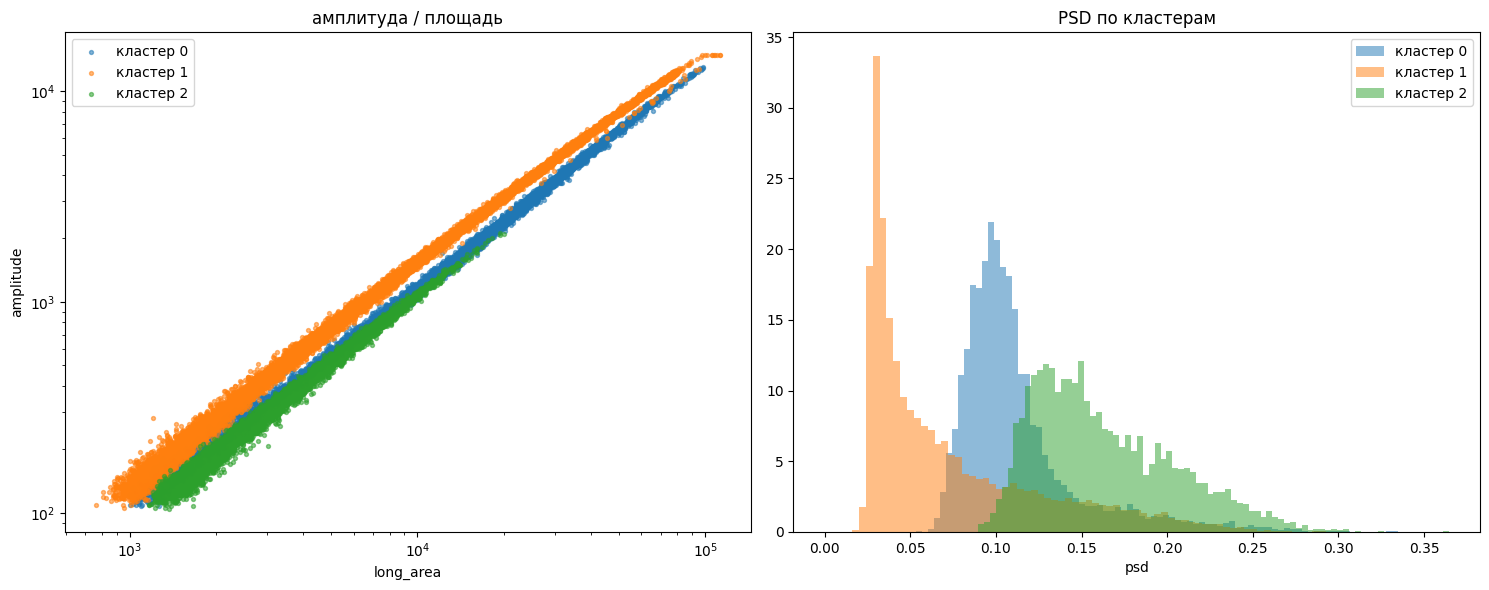

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for cl in [0, 1, 2]:
    sub = features_lbl[features_lbl.cluster == cl]
    ax[0].scatter(sub.long_area, sub.amplitude, s=8, alpha=0.55, label=f"кластер {cl}")
ax[0].set(xscale="log", yscale="log", xlabel="long_area", ylabel="amplitude",
          title="амплитуда / площадь")
ax[0].legend()

for cl in [0, 1, 2]:
    sub = features_lbl[features_lbl.cluster == cl]
    ax[1].hist(sub.psd, bins=80, alpha=0.5, density=True, label=f"кластер {cl}")
ax[1].set(title="PSD по кластерам", xlabel="psd")
ax[1].legend()
plt.tight_layout(); plt.show()

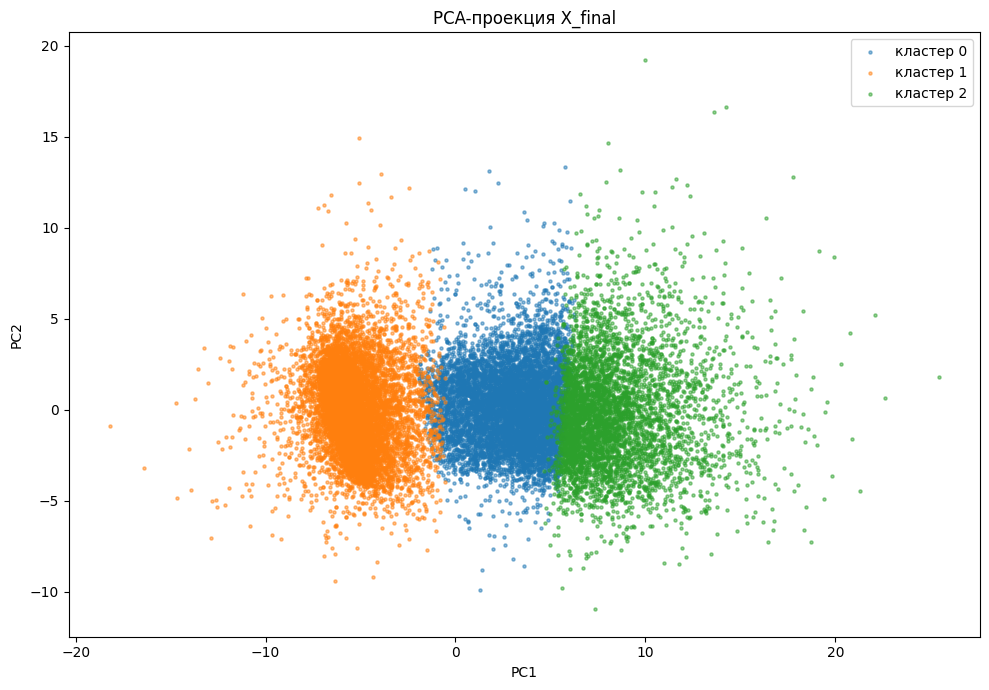

In [20]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_final)
fig, ax = plt.subplots(figsize=(10, 7))
for cl in [0, 1, 2]:
    m = labels_final == cl
    ax.scatter(pca_2d[m, 0], pca_2d[m, 1], s=5, alpha=0.5, label=f"кластер {cl}")
ax.set(title="PCA-проекция X_final", xlabel="PC1", ylabel="PC2")
ax.legend()
plt.tight_layout(); plt.show()

Если смотреть на медианы: первый кластер — заметная амплитуда, PSD около 0.13, длинный хвост,
это нейтроны (медленная компонента сильнее). Второй — амплитуда тоже большая, но PSD низкий,
около 0.06, хвост короткий — гамма. Третий — слабые события с плавающим PSD: шумовые,
пограничные, всё, что не поддалось.

Сами номера 0/1/2 модель не знает, их раскидывает `remap_three` после кластеризации по медианам.

## Важность признаков

У KMeans нет своего FeatureImportance. Подгоню RandomForest поверх меток, чтобы посмотреть, на чём именно
кластеры разделяются. Это не оправдание модели, а способ объяснить разбиение.

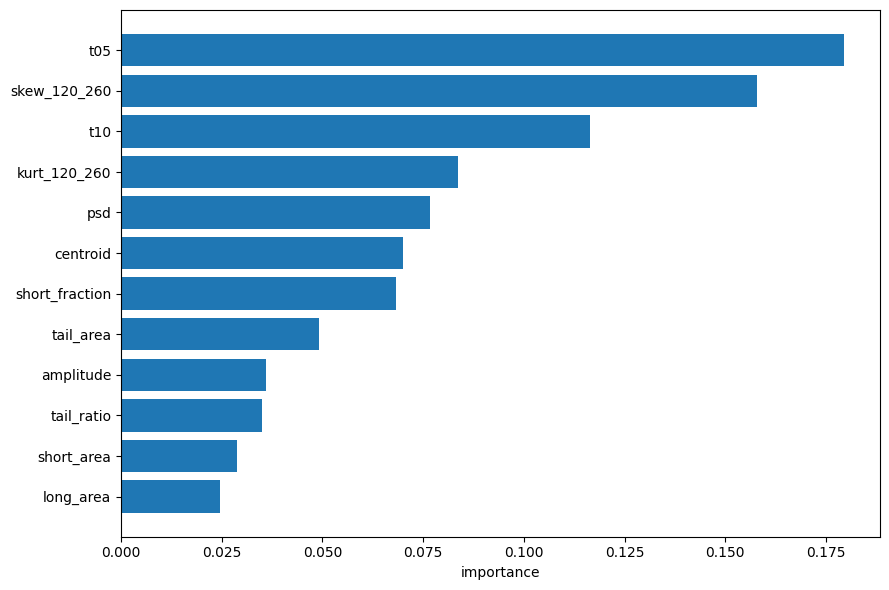

,feature,importance
0,t05,0.1794
1,skew_120_260,0.1579
2,t10,0.1164
3,kurt_120_260,0.0837
4,psd,0.0768
5,centroid,0.0699
6,short_fraction,0.0683
7,tail_area,0.0490
8,amplitude,0.0359
9,tail_ratio,0.0350


In [21]:
imp_cols = ["amplitude", "long_area", "short_area", "tail_area",
            "psd", "short_fraction", "tail_ratio",
            "t05", "t10", "t25", "t50", "rise_10_90",
            "peak_position", "pre_std", "tail_std",
            "centroid", "width", "skew_120_260", "kurt_120_260"]

rf = RandomForestClassifier(n_estimators=400, max_depth=8,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(features[imp_cols], labels_final)

imp = (pd.DataFrame({"feature": imp_cols, "importance": rf.feature_importances_})
       .sort_values("importance", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.head(12)["feature"][::-1], imp.head(12)["importance"][::-1])
ax.set(xlabel="importance")
plt.tight_layout(); plt.show()

imp.head(12).round(4)

На первых местах ожидаемо амплитуда и площади плюс PSD и tail_ratio. То есть кластеризация
разводится ровно на тех признаках, ради которых их и считали.

## Submission

In [22]:
submission = pd.DataFrame({
    "index":   np.arange(len(labels_final), dtype=np.int32),
    "cluster": labels_final.astype(np.int16),
})

assert submission.shape == (23479, 2)
assert submission.columns.tolist() == ["index", "cluster"]
assert set(submission.cluster.unique()) == {0, 1, 2}

submission.to_csv(SUBMISSION_PATH, index=False)
print("submission saved:", SUBMISSION_PATH)
print("распределение:", submission.cluster.value_counts().sort_index().to_dict())
submission.head()

submission saved: submission.csv
распределение: {0: 7358, 1: 11302, 2: 4819}


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


## Лидерборд

Скрин публичного лидерборда соревнования с моим текущим положением и public score.

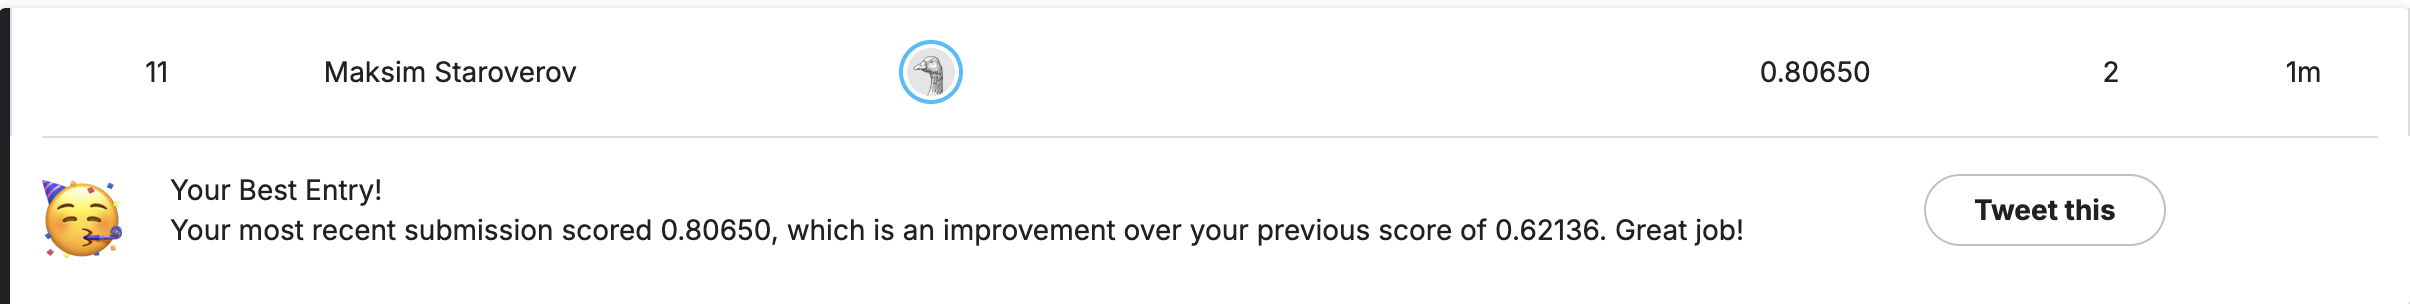


## Итог

Идея решения держится на физике: гамму и нейтрон в паратерфениле разводят по форме хвоста, а слабые
события с шумовой PSD естественно собираются в отдельный третий класс. Под это собрал признаки и
прогнал несколько кластеризаций — правило по PSD, KMeans, GMM с разными ковариациями, GMM-2 с
пометкой аномалий и IsolationForest + GMM-2.

В итоге беру KMeans на 25-мерной матрице (логи положительных признаков + знаковые статистики формы
+ 5 главных компонент нормированной формы импульса) с весами `amp_w=0.52`, `tail_w=0.95`.
Размеры кластеров 7358 / 11302 / 4819. Public score на Kaggle — 0.80650.

Всё воспроизводится запуском ноутбука сверху вниз при `random_state=42`.